# Park Task
We set up 2 actions that will differ in *yaw angle* and *required force*. \
The actions are:
- Discrete action: pull left at +5˚, Continuous kinematics: force 3g (peak)
- Discrete action: pull right at -15˚, Continuous kinematics: force 12g (peak)

We produce beta distributions from the range 1 - 15g. One bundle peaks at 3g (pull left) and another at 12g (pull right). 
We encode these distributions as 512D bundle vectors. 

Therefore, we have:
- 2 action channels: pull left vs. pull right
- Continuous action parameter (force): 3g (peak for pull left) and 12g (peak for pull right)

We create a 2x2 action grid experimental design 
|Left| Right|
|---|---|
|L @ 3g | R @ 12g|
|L @ 12g| R @ 3g|



In this case, we will have 2 discrete channels - left and right. \
Each channel will have a continous action space over the force domain [0, 15]g. \
The distribution over the left channel will have bumps/peaks at 3g and 12g. \
The distribution over the right channel will have bumps/peaks at 3g and 12g. \\

4 trials with 2 channels for left and right:
1. L3 vs. R12 - L3 is the winning channel 
2. L3 vs. R12 - R12 is the winning channel 
3. L12 vs. R3 - L12 is the winning channel 
4. L12 vs. R3 - R3 is the winning channel 

----

# Imports

In [1]:
# Add imports 
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from sspspace.sspspace.encoders import RandomSSPSpace

import nengo
from nengo.network import Network
from nengo import Node, Connection

# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility, ActionIterator, DataStorage

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create Distributions & Bundles 

In [2]:
# ================================================
# 1. Define continuous force domain & SSP encoder
# ================================================
n_actions_park = 2
domain_force_park = np.arange(0, 15, 0.01).reshape(-1, 1) # Shape: (1500, 1)
ssp_dim_park = 512

# SSP encoder for scalar force values
ssp_encoder_park = RandomSSPSpace(
    domain_dim=1,
    ssp_dim=ssp_dim_park,
    rng=np.random.RandomState(0),
    length_scale=0.5
)
# Convert domain values to high-dimensional SSPs
domain_phis_park = ssp_encoder_park.encode(domain_force_park)  # shape: (1500, 512)
# print(domain_phis.shape)

# Place cell encoders for Nengo ensembles
low = 0
high = 15
width = high - low
places_park = np.arange(low, high, width/(domain_force_park.shape[0]))
dnf_encoders_park = np.asarray(ssp_encoder_park.encode(places_park.reshape(-1, 1))).squeeze() # Shape: (1500, 512)
# print(dnf_encoders.shape) # (512, 1500)

# ================================================
# 2. DNF Parameters
# ================================================
dnf_params_park = {
            'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions_park, 1500)], 
            'beta'            : 4,
    }


# ================================================
# 3. Generate two bundle vectors via Beta PDFs
#    Peaked at 3g and 12g respectively
# ================================================
# Beta shapes chosen so mode(a-1)/(a+b-2) matches desired peak/domain
scale = 15
# 1. Choose 4 random peak heights 
peak_heights = np.random.uniform(low=0.1, high=1.0, size=4) 
# 2. Make left and right distribution with peaks at 3 and 12
# Trick: α controls skew toward right, β toward left
# For left channel 
l3 = beta.pdf(domain_force_park, 2, 5, scale=scale) # peak at 3
l12 = beta.pdf(domain_force_park, 5, 2, scale=scale) # peak at 12
# For right channel
r3 = beta.pdf(domain_force_park, 2, 5, scale=scale) # peak at 3
r12 = beta.pdf(domain_force_park, 5, 2, scale=15) # peak at 12

distributions = [l3, l12, r3, r12]

# Combine them
# y = peak1 + peak2
# normalize > scale by saliece > combine the peaks > bundle 

# ========================================
# 4. Salience values for actions
# ========================================
# Trial 1: [L3, L12, R3, R12] - L3 wins
salience_t1 = [0.93, 0.22, 0.55, 0.61]
# Trial 2: [L3, L12, R3, R12] - L12 wins
salience_t2 = [0.25, 0.95, 0.5, 0.63]
# Trial 3: [L3, L12, R3, R12] - R3 wins
salience_t3 = [0.45, 0.62, 0.98, 0.33]
# Trial 4: [L3, L12, R3, R12] - R12 wins
salience_t4 = [0.50, 0.65, 0.40, 0.93]


# ========================================
# 5. Create bundles for the 4 sets of trials 
# ========================================
# Trial 1:
trial1 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t1, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial2 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t2, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial3 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t3, Utility.to_normalize(distributions))), domain_phis_park)
# Trial 2: 
trial4 = Utility.to_bundle(Utility.to_bimodal(Utility.to_scale(salience_t4, Utility.to_normalize(distributions))), domain_phis_park)
# All trials
trials = [trial1, trial2, trial3, trial4]


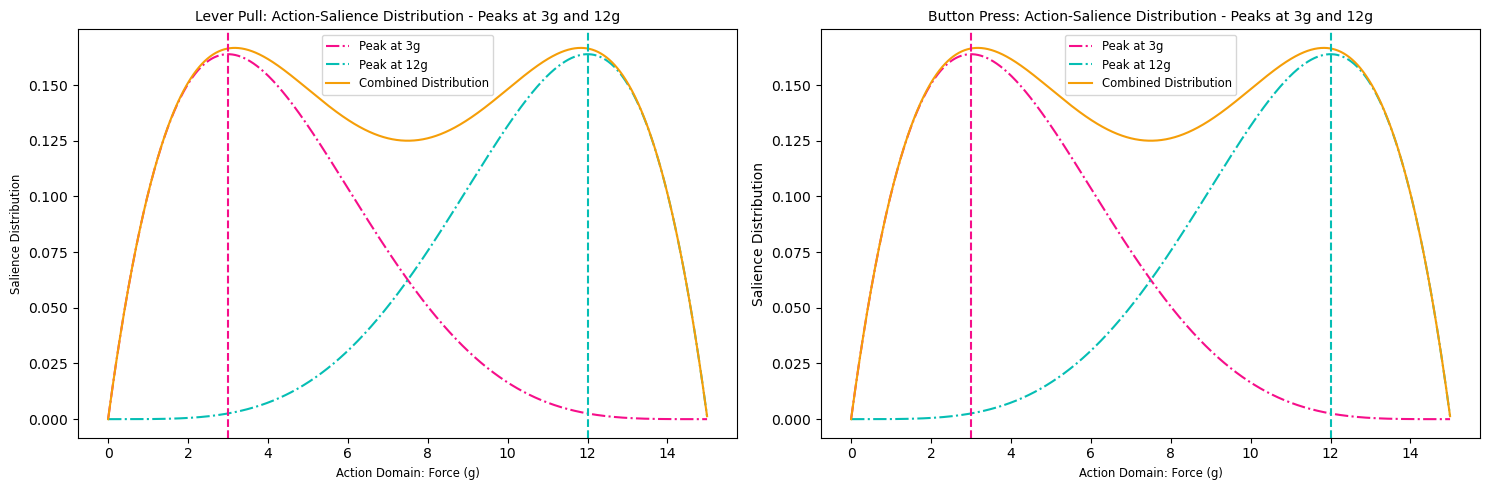

In [3]:
# ========================================
# 6. Plot the Beta distributions for each channel
# ========================================
# Plot the left and right distributions 
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
# -------------------------------
# Plot the Left distribution 
# ---------------------------
left = l3 + l12 # combined bimodal
axes1[0].plot(domain_force_park, l3, color="#f60c89fd", linestyle='-.', label='Peak at 3g')
axes1[0].plot(domain_force_park, l12, color="#05beb4", linestyle='-.', label='Peak at 12g')
axes1[0].plot(domain_force_park, left, color="#f59e08", label='Combined Distribution')
axes1[0].axvline(x=3, linestyle='--', color="#f60c89fd")
axes1[0].axvline(x=12, linestyle='--', color="#05beb4")
axes1[0].legend(loc='best', fontsize='small')
axes1[0].set_title("Lever Pull: Action-Salience Distribution - Peaks at 3g and 12g", fontsize='medium')
axes1[0].set_xlabel("Action Domain: Force (g)", fontsize='small')
axes1[0].set_ylabel("Salience Distribution", fontsize='small')
# -------------------------------
# Plot the Right distribution 
# ---------------------------
right = r3 + r12 # combined bimodal
axes1[1].plot(domain_force_park, r3, color="#f60c89fd", linestyle='-.', label='Peak at 3g')
axes1[1].plot(domain_force_park, r12, color="#05beb4", linestyle='-.', label='Peak at 12g')
axes1[1].plot(domain_force_park, right, color="#f59e08", label='Combined Distribution')
axes1[1].axvline(x=3, linestyle='--', color="#f60c89fd")
axes1[1].axvline(x=12, linestyle='--', color="#05beb4")
axes1[1].legend(loc='best', fontsize='small')
axes1[1].set_title("Button Press: Action-Salience Distribution - Peaks at 3g and 12g", fontsize='medium')
axes1[1].set_xlabel("Action Domain: Force (g)", fontsize='small')
axes1[1].set_ylabel("Salience Distribution")

plt.tight_layout()
# plt.savefig('./figures/park/bimodal/distribution.png')
plt.savefig('./figures/park/bimodal/paper_distribution.png')
plt.show()


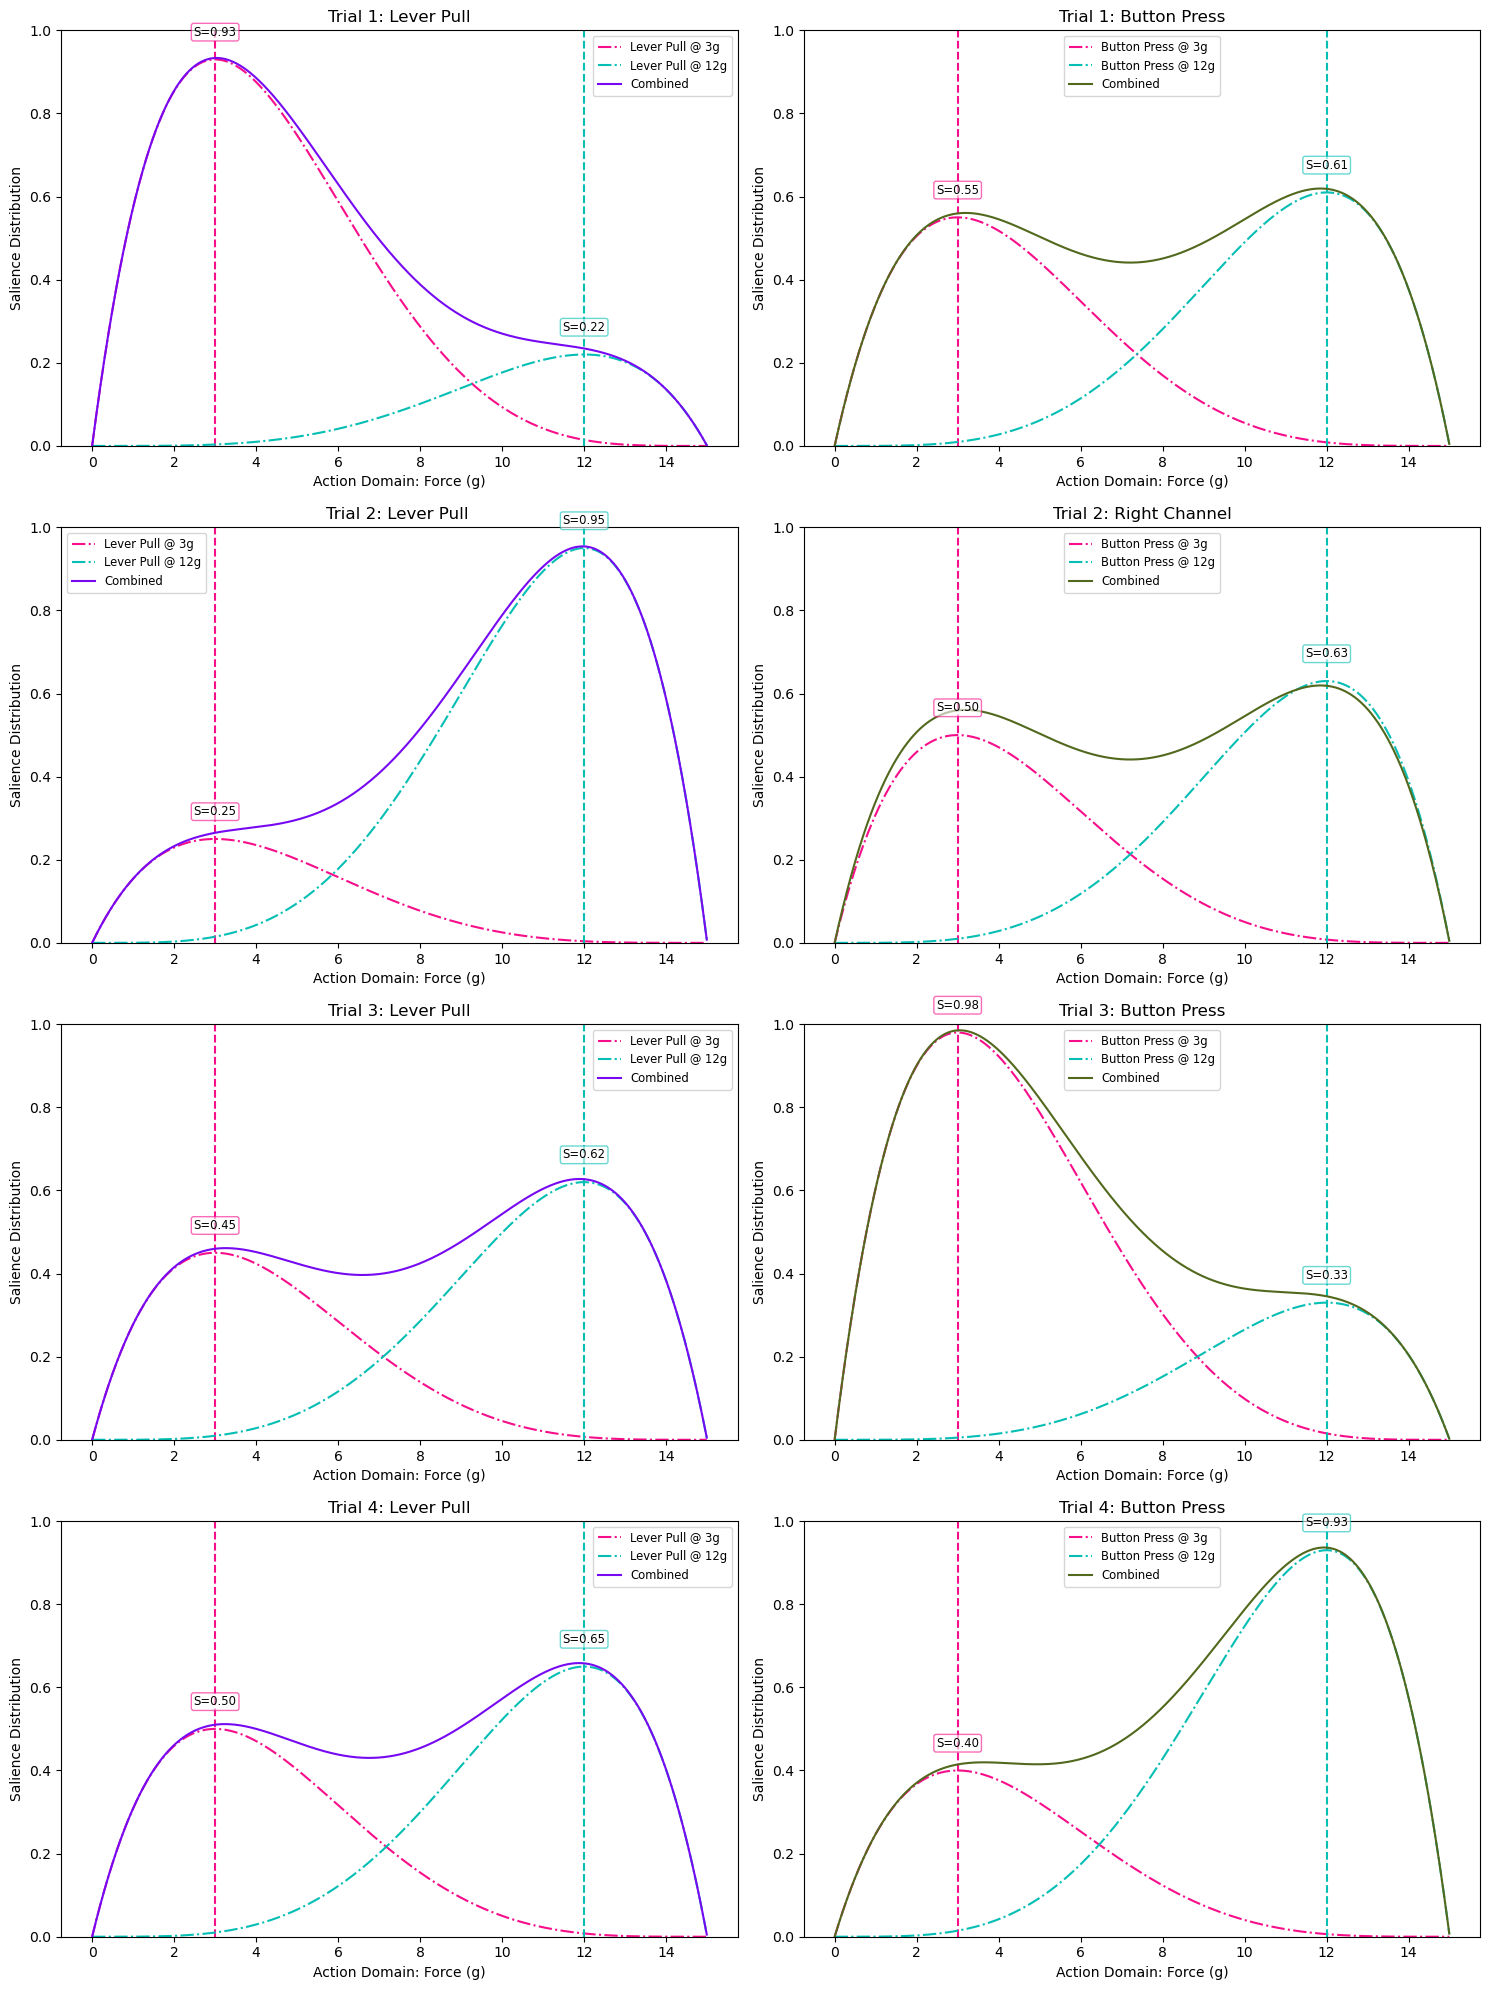

In [4]:
# ========================================
# 7. Plot the salience scaled beta distribution for each channel
# ========================================
colors = ["#f60c89fd", "#05beb4"]
actions_left = ['Lever Pull @ 3g', 'Lever Pull @ 12g']
actions_right = ['Button Press @ 3g', 'Button Press @ 12g']
peak = [3, 12]

# create 4×2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 20),)

# ---------------------------------
# Trial 1: L3 vs. R12 - L3 wins!
# ---------------------------------
# (0,0): Left
t1_left = Utility.to_scale(salience=salience_t1[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left1 = t1_left[0] + t1_left[1]
for i, pdf in enumerate(t1_left):
    axes[0, 0].plot(domain_force_park, pdf, color=colors[i],
                    label=f'{actions_left[i]}', linestyle='-.')
    axes[0, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[0, 0].text(
        peak[i], salience_t1[i] + 0.05,   # place just above peak
        f"S={salience_t1[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[0, 0].plot(domain_force_park, scaled_left1, color="#7609f2", label="Combined")
axes[0, 0].set_title('Trial 1: Lever Pull', fontsize='large')
axes[0, 0].set_xlabel('Action Domain: Force (g)')
axes[0, 0].set_ylabel("Salience Distribution")
axes[0, 0].set_ylim(0, 1.0)
axes[0, 0].legend(fontsize='small')

# (0,1): Right
t1_right = Utility.to_scale(salience=salience_t1[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right1 = t1_right[0] + t1_right[1]
for j, pdf in enumerate(t1_right):
    idx = j + 2   # salience indices for right channel
    axes[0, 1].plot(domain_force_park, pdf, color=colors[j],
                    label=f'{actions_right[j]}', linestyle='-.')
    axes[0, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[0, 1].text(
        peak[j], salience_t1[idx] + 0.05,
        f"S={salience_t1[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[0, 1].plot(domain_force_park, scaled_right1, color="#52681D", label="Combined")
axes[0, 1].set_title('Trial 1: Button Press', fontsize='large')
axes[0, 1].set_xlabel('Action Domain: Force (g)')
axes[0, 1].set_ylabel('Salience Distribution')
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].legend(fontsize='small')


# ------------------------
# Trial 2: L3 vs. R12 - R12 wins!
# -----------------------
# (1, 0): Left
t2_left = Utility.to_scale(salience=salience_t2[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left2 = t2_left[0] + t2_left[1]
for i, pdf in enumerate(t2_left):
    axes[1, 0].plot(domain_force_park, pdf, color=colors[i],
                    label=f'{actions_left[i]}', linestyle='-.')
    axes[1, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[1, 0].text(
        peak[i], salience_t2[i] + 0.05,   # place just above peak
        f"S={salience_t2[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[1, 0].plot(domain_force_park, scaled_left2, color="#7609f2", label="Combined")
axes[1, 0].set_title('Trial 2: Lever Pull ', fontsize='large')
axes[1, 0].set_xlabel('Action Domain: Force (g)')
axes[1, 0].set_ylabel("Salience Distribution")
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].legend(fontsize='small')

# (1, 1): Right
t2_right = Utility.to_scale(salience=salience_t2[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right2 = t2_right[0] + t2_right[1]
for j, pdf in enumerate(t2_right):
    idx = j + 2   # salience indices for right channel
    axes[1, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[1, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[1, 1].text(
        peak[j], salience_t2[idx] + 0.05,
        f"S={salience_t2[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[1, 1].plot(domain_force_park, scaled_right1, color="#52681D", label="Combined")
axes[1, 1].set_title('Trial 2: Right Channel', fontsize='large')
axes[1, 1].set_xlabel('Action Domain: Force (g)')
axes[1, 1].set_ylabel('Salience Distribution')
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].legend(fontsize='small')

# ------------------------
# Trial 3: L12 vs. R3 - L12 wins!
# -----------------------
# (2, 0): Left
t3_left = Utility.to_scale(salience=salience_t3[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left3 = t3_left[0] + t3_left[1]
for i, pdf in enumerate(t3_left):
    axes[2, 0].plot(domain_force_park, pdf, color=colors[i], label=f'{actions_left[i]}', linestyle='-.') # type: ignore
    axes[2, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[2, 0].text(
        peak[i], salience_t3[i] + 0.05,   # place just above peak
        f"S={salience_t3[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[2, 0].plot(domain_force_park, scaled_left3, color="#7609f2", label="Combined")
axes[2, 0].set_title('Trial 3: Lever Pull', fontsize='large')
axes[2, 0].set_xlabel('Action Domain: Force (g)')
axes[2, 0].set_ylabel("Salience Distribution")
axes[2, 0].set_ylim(0, 1.0)
axes[2, 0].legend(fontsize='small')

# # (2, 1): Right
t3_right = Utility.to_scale(salience=salience_t3[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right3 = t3_right[0] + t3_right[1]
for j, pdf in enumerate(t3_right):
    idx = j + 2   # salience indices for right channel
    axes[2, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[2, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[2, 1].text(
        peak[j], salience_t3[idx] + 0.05,
        f"S={salience_t3[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[2, 1].plot(domain_force_park, scaled_right3, color="#52681D", label="Combined")
axes[2, 1].set_title('Trial 3: Button Press', fontsize='large')
axes[2, 1].set_xlabel('Action Domain: Force (g)')
axes[2, 1].set_ylabel('Salience Distribution')
axes[2, 1].set_ylim(0, 1.0)
axes[2, 1].legend(fontsize='small')

# ------------------------
# Trial 4: L12 vs. R3 - R3 wins!
# -----------------------
# (3, 0): Left
t4_left = Utility.to_scale(salience=salience_t4[:2], normalized_distributions=Utility.to_normalize([l3, l12]))
scaled_left4 = t4_left[0] + t4_left[1]
for i, pdf in enumerate(t4_left):
    axes[3, 0].plot(domain_force_park, pdf, color=colors[i], label=f'{actions_left[i]}', linestyle='-.')
    axes[3, 0].axvline(x=peak[i], color=colors[i], linestyle='--')
    # Add label for peak height
    axes[3, 0].text(
        peak[i], salience_t4[i] + 0.05,   # place just above peak
        f"S={salience_t4[i]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], alpha=0.6))
axes[3, 0].plot(domain_force_park, scaled_left4, color="#7609f2", label="Combined")
axes[3, 0].set_title('Trial 4: Lever Pull', fontsize='large')
axes[3, 0].set_xlabel('Action Domain: Force (g)')
axes[3, 0].set_ylabel("Salience Distribution")
axes[3, 0].set_ylim(0, 1.0)
axes[3, 0].legend(fontsize='small')

# # (2, 1): Right
t4_right = Utility.to_scale(salience=salience_t4[2:], normalized_distributions=Utility.to_normalize([r3, r12]))
scaled_right4 = t4_right[0] + t4_right[1]
for j, pdf in enumerate(t4_right):
    idx = j + 2   # salience indices for right channel
    axes[3, 1].plot(domain_force_park, pdf, color=colors[j],
                   label=f'{actions_right[j]}', linestyle='-.')
    axes[3, 1].axvline(x=peak[j], color=colors[j], linestyle='--')
    # Add label for peak height
    axes[3, 1].text(
        peak[j], salience_t4[idx] + 0.05,
        f"S={salience_t4[idx]:.2f}",
        ha='center', va='bottom', fontsize='small',
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[j], alpha=0.6))
axes[3, 1].plot(domain_force_park, scaled_right4, color="#52681D", label="Combined")
axes[3, 1].set_title('Trial 4: Button Press', fontsize='large')
axes[3, 1].set_xlabel('Action Domain: Force (g)')
axes[3, 1].set_ylabel('Salience Distribution')
axes[3, 1].set_ylim(0, 1.0)
axes[3, 1].legend(fontsize='small')

plt.tight_layout()
# plt.savefig('./figures/park/bimodal/trial_distribution.png')
plt.savefig('./figures/park/bimodal/paper_trial_distribution.png')
plt.show()

# Conduct Trials

In [5]:
# Run the trials and collect data 
def trial(bundles, n_actions, dnf_parameters, encoders, ssp_size = 512, d1_weight = 1.0, d2_weight = 1.0, dopamine_level = 0.2):
    assert len(bundles) == n_actions, "The number of input bundles and action channels is not the same"
    # DNF/BG Parameters
    d1_weight = d1_weight
    d2_weight = d2_weight
    dopamine_level = dopamine_level
    
    # Basal Ganglia model
    bg_model = BasalGanglia(n_actions=n_actions, dnf_parameters=dnf_parameters, encoders=encoders, dnf_neurons = 1500)
    # Add custom probes - probes input, neuron actitivies, output of gpe, gpi and stn 
    bg_model.add_probe('gpe', index=None, what='neurons', field='input') # input to gpe
    bg_model.add_probe('gpe', index=None, what='neurons') # neuron activities 
    bg_model.add_probe('gpi', index=None, what='neurons', field='input') # input to gpi
    bg_model.add_probe('gpi', index=None, what='neurons') # neuron activities 
    bg_model.add_probe('stn', index=None, what='neurons', field='input') # input to stn
    bg_model.add_probe('stn', index=None, what='neurons') # neuron activities 
    
    data = bg_model.simulate(input_bundles=bundles, dopamine_level=dopamine_level, presentation_time=1.5, duration=1.5)
    return data


# Run the 4 trials
run_trial1 = trial(trial1, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial2 = trial(trial2, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial3 = trial(trial3, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)
run_trial4 = trial(trial4, n_actions=2, dnf_parameters = dnf_params_park, encoders=dnf_encoders_park)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

In [6]:
# run_trial1.keys()
# {
#           'bundle_ins': [np.ndarray, ...],
#           'd1_input': np.ndarray, 
#           'd1_neuron': np.ndarray,
#           'd2_input': np.ndarray, 
#           'd2_neuron': np.ndarray,
#           'bundle_out': np.ndarray,
#           'custom_probes': { ... nested dicts/lists/ndarrays ... }
#         }
run_trial1.keys()

dict_keys(['bundle_ins', 'd1_input', 'd1_neuron', 'd2_input', 'd2_neuron', 'bundle_out', 'custom_probes'])

In [7]:
# Save trail data
# Add model data 
meta = {
    'model': 'basal_ganglia_2025_park_bimodal',
    'n_actions': 2,
    'domain': '[0, 15]',
    'domain_step': '0.01',
    'sim_time': 1.5,
    'dopamine_level': 0.2,
    'd1_weight': 1.0,
    'd2_weight': 1.0,
    'salience': {
        't1_salience': salience_t1,
        't2_salience': salience_t2,
        't3_salience': salience_t3,
        't4_salience': salience_t4,
    },
    'description': 'BG model for Park'
}

# result1 = run_trial1
run_trial1['original_distributions'] = distributions
run_trial2['original_distributions'] = distributions
run_trial3['original_distributions'] = distributions
run_trial4['original_distributions'] = distributions

# Save raw model data
ds = DataStorage(base_dir='bg_data')  # ensures ./bg_data/, ./bg_data/json, ./bg_data/npz exist

# Save both variants
# Trial 1
npz_path1 = ds.save_npz(data=run_trial1, meta=meta, run_id = 'park_bimodal/trial1')        # -> ./bg_data/npz/<run_id>.npz
json_dir1 = ds.save_json(data=run_trial1, meta=meta, run_id = 'park_bimodal/trial1')       # -> ./bg_data/json/<run_id>/
# Trial 2
npz_path2 = ds.save_npz(data=run_trial2, meta=meta, run_id = 'park_bimodal/trial2')        # -> ./bg_data/npz/<run_id>.npz
json_dir2 = ds.save_json(data=run_trial2, meta=meta, run_id = 'park_bimodal/trial2')  
# Trial 3
npz_path3 = ds.save_npz(data=run_trial3, meta=meta, run_id = 'park_bimodal/trial3')        # -> ./bg_data/npz/<run_id>.npz
json_dir3 = ds.save_json(data=run_trial3, meta=meta, run_id = 'park_bimodal/trial3')  
# Trial 4
npz_path4 = ds.save_npz(data=run_trial4, meta=meta, run_id = 'park_bimodal/trial4')        # -> ./bg_data/npz/<run_id>.npz
json_dir4 = ds.save_json(data=run_trial4, meta=meta, run_id = 'park_bimodal/trial4')  
# Load later by run_id inferred from file location:
loaded_npz, meta_npz = ds.load_npz(npz_path2)     # or ds.load_npz("<run_id>")
loaded_jsn, meta_jsn = ds.load_json(json_dir3)    # or ds.load_json("<run_id>")

# Generate Plots

## Input Bundle Plots vs. Original Beta Distributions

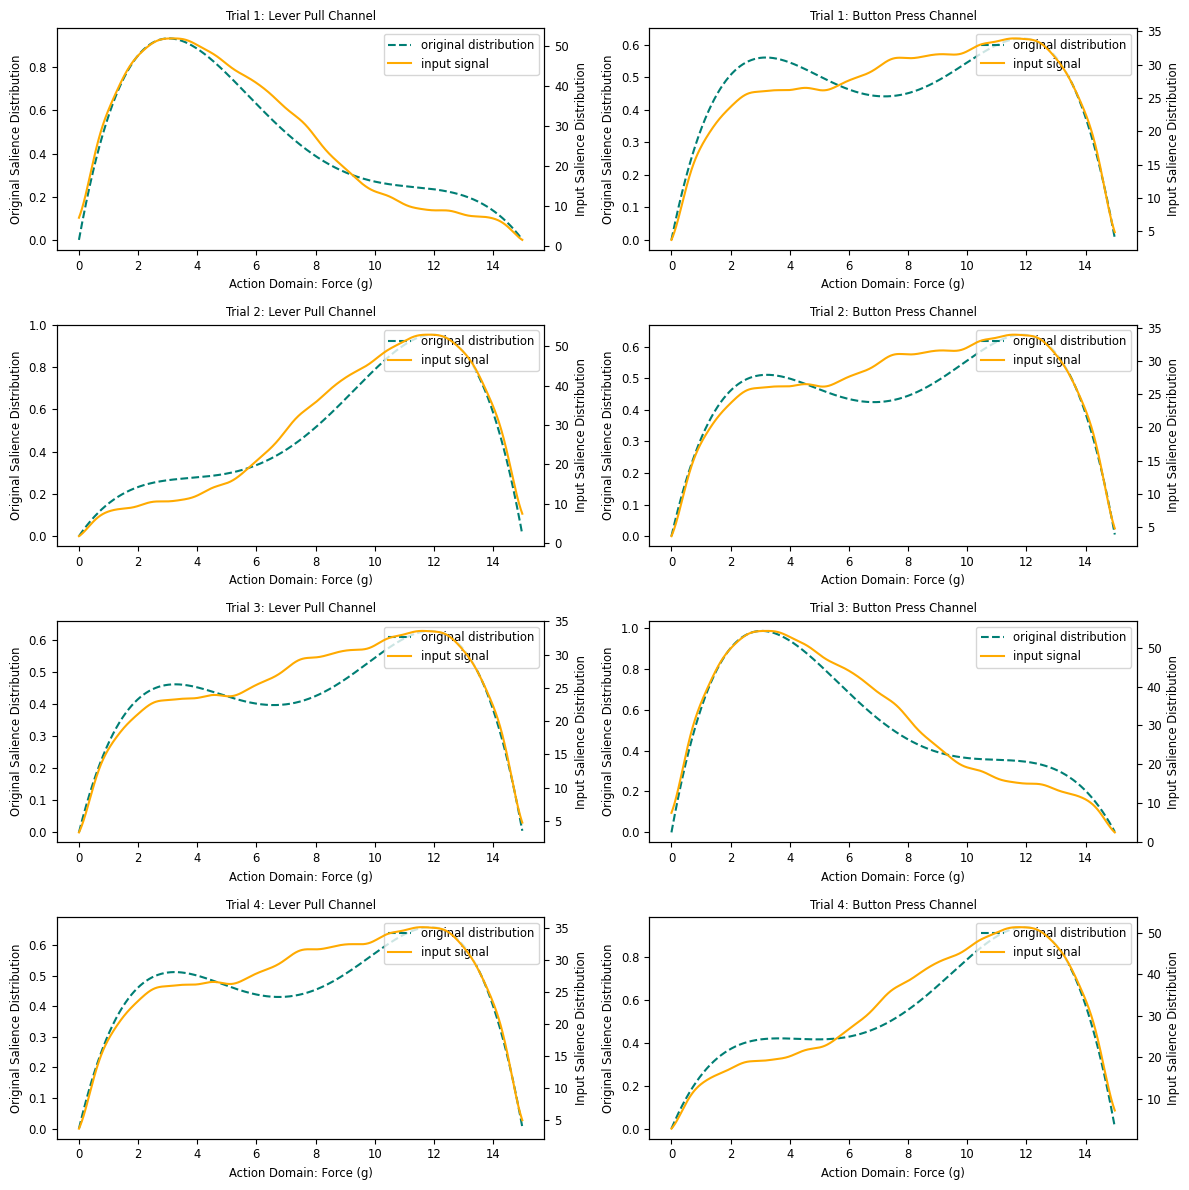

In [8]:
def plot_input_bundles(org_dist, bundle_dist, axes, trial_int, action_labels, salience_plot):
    ax = axes[trial_int]
    for i in range(n_actions_park):
        # Primary y-axis: input distribution
        ax[i].plot(domain_force_park.squeeze(), org_dist[i], ls='--', color="#007e74", label="original distribution")
        ax[i].set_xlabel("Action Domain: Force (g)", fontsize="small")
        ax[i].set_ylabel("Original Salience Distribution", fontsize="small")
        ax[i].tick_params(axis='x', labelsize='small')
        ax[i].tick_params(axis='y', labelsize='small')

        ax2 = ax[i].twinx()
        ax2.plot(domain_force_park.squeeze(), bundle_dist[i], ls='-', color="#ffaa00", label="input signal")
        ax2.set_ylabel("Input Salience Distribution", fontsize="small")
        ax2.tick_params(axis='y', labelsize='small')

        # Combined legend
        h1, l1 = ax[i].get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax[i].legend(h1 + h2, l1 + l2, loc='upper right', fontsize='small')

        ax[i].set_title(f'Trial {trial_int + 1}: {action_labels[i]} Channel', fontsize='small')


# Create a 4 x 2 grid 
fig, axes = plt.subplots(4, 2, figsize=(12, 12))

# Trail 1 
bin_l_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][1][-1], domain_phis_park)

# Trial 2
bin_l_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][1][-1], domain_phis_park)

# Trial 3
bin_l_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][1][-1], domain_phis_park)

# Trial 4
bin_l_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][0][-1], domain_phis_park)
bin_r_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][1][-1], domain_phis_park)

if n_actions_park == 1:
    axes = [axes]

plot_input_bundles([scaled_left1, scaled_right1], [bin_l_dist1, bin_r_dist2], axes, trial_int = 0, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t1)
plot_input_bundles([scaled_left2, scaled_right2], [bin_l_dist2, bin_r_dist2], axes, trial_int = 1, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t2)
plot_input_bundles([scaled_left3, scaled_right3], [bin_l_dist3, bin_r_dist3], axes, trial_int = 2, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t3)
plot_input_bundles([scaled_left4, scaled_right4], [bin_l_dist4, bin_r_dist4], axes, trial_int = 3, action_labels=['Lever Pull', 'Button Press'], salience_plot=salience_t4)
plt.tight_layout()
# plt.savefig('./figures/park/bimodal/input_bundles_park.png')
plt.savefig('./figures/park/bimodal/paper_input_bundles.png')
plt.show()




## DNF - D1 & D2

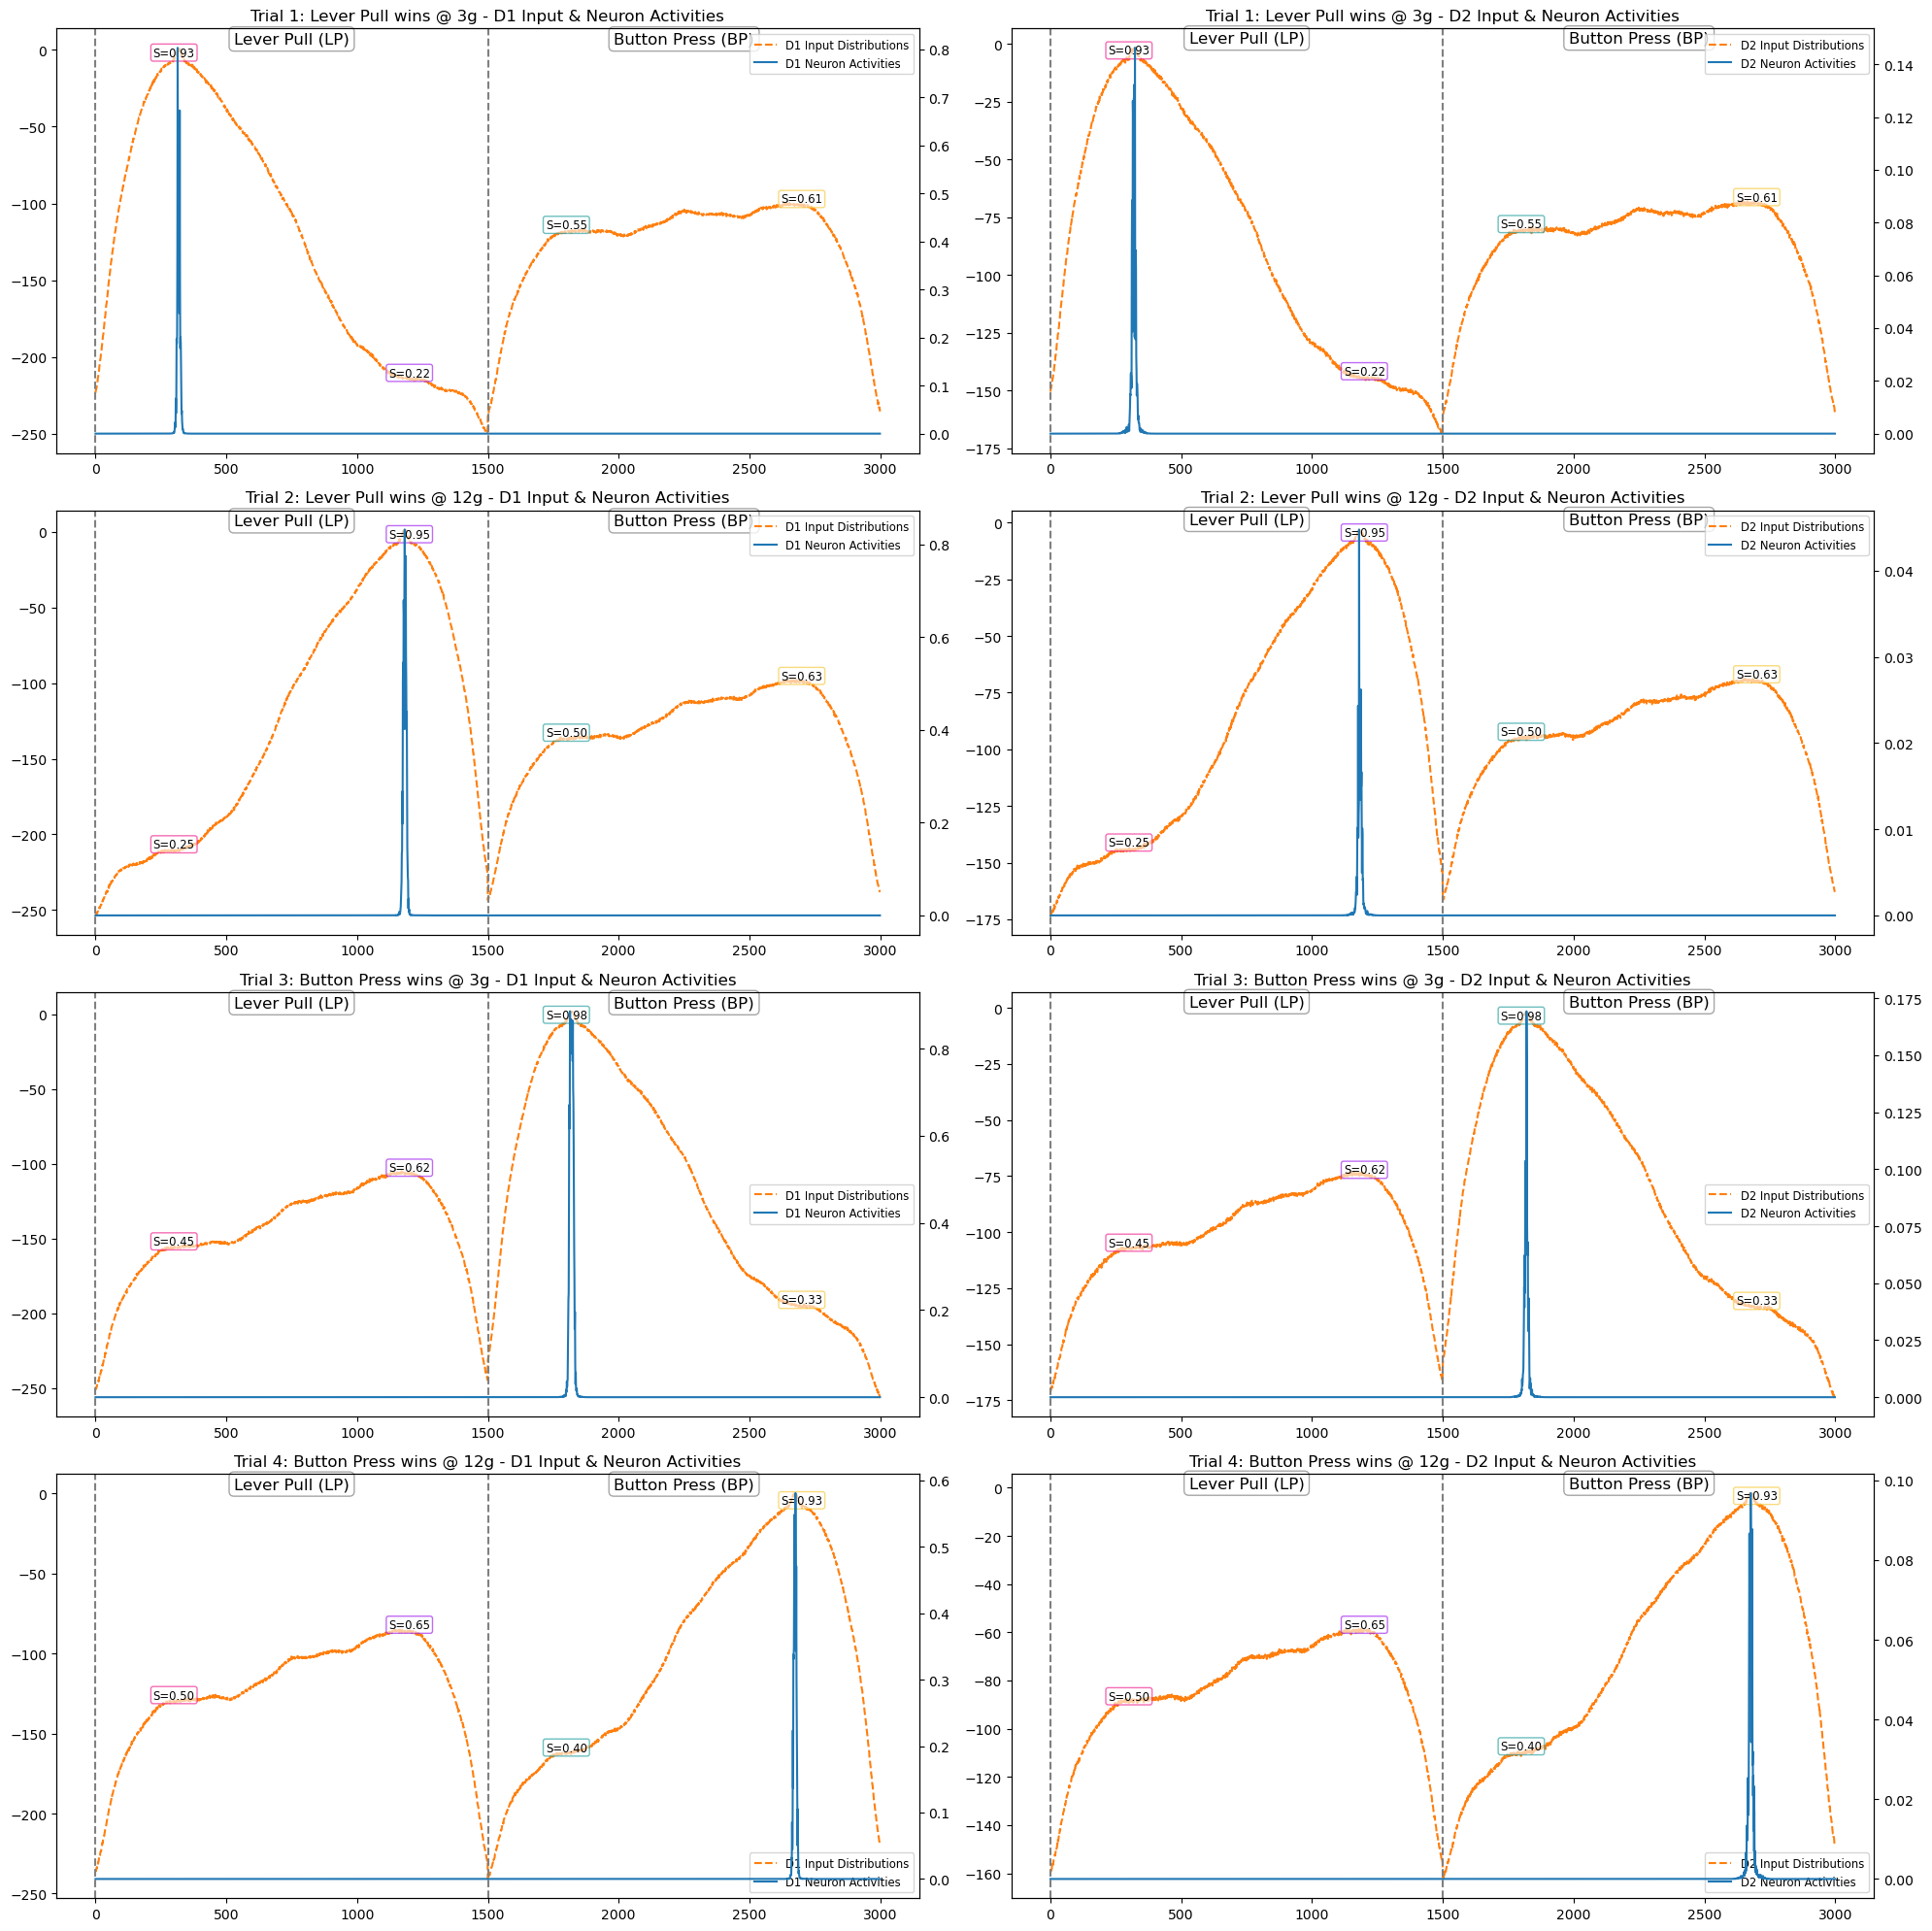

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(4, 2, figsize=(20, 20))
trial_labels = ['Lever Pull wins @ 3g', 'Lever Pull wins @ 12g', 'Button Press wins @ 3g', 'Button Press wins @ 12g']
data_trials = [run_trial1, run_trial2, run_trial3, run_trial4]
action_labels = ['Lever Pull (LP)', 'Button Press (BP)']
peak_labels = [300, 1200, 1800, 2700]  # example peak x-positions
colors = ["#ef0a84", "#970aef", "#0d9494", "#f6c226"]
salience_labels = [salience_t1, salience_t2, salience_t3, salience_t4]

for i in range(4):  # 4 trials
    # ------------------- D1 PANEL -------------------
    axes[i, 0].plot(
        data_trials[i]['d1_input'][-1],
        label='D1 Input Distributions',
        linestyle='--', color='C1'
    )
    ax2 = axes[i, 0].twinx()
    ax2.plot(data_trials[i]['d1_neuron'][-1], label='D1 Neuron Activities')

    h1, l1 = axes[i, 0].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    axes[i, 0].legend(h1 + h2, l1 + l2, loc='best', fontsize='small')
    axes[i, 0].set_title(f"Trial {i+1}: {trial_labels[i]} - D1 Input & Neuron Activities")

    # ------------------- D2 PANEL -------------------
    axes[i, 1].plot(
        data_trials[i]['d2_input'][-1],
        label='D2 Input Distributions',
        linestyle='--', color='C1'
    )
    ax3 = axes[i, 1].twinx()
    ax3.plot(data_trials[i]['d2_neuron'][-1], label='D2 Neuron Activities')

    h3, l3 = axes[i, 1].get_legend_handles_labels()
    h4, l4 = ax3.get_legend_handles_labels()
    axes[i, 1].legend(h3 + h4, l3 + l4, loc='best', fontsize='small')
    axes[i, 1].set_title(f"Trial {i+1}: {trial_labels[i]} - D2 Input & Neuron Activities")

    # ------------------- ADD CHANNEL LINES & LABELS -------------------
    for k in range(n_actions_park):
        xpos = k * domain_force_park.shape[0]
        axes[i, 0].axvline(xpos, linestyle='--', color='grey')
        axes[i, 1].axvline(xpos, linestyle='--', color='grey')

        if k < n_actions_park - 1:
            next_xpos = (k + 1) * domain_force_park.shape[0]
            x_text = (xpos + next_xpos) / 2
        else:
            x_text = xpos + domain_force_park.shape[0] / 2

        y_text0 = axes[i, 0].get_ylim()[1] * 0.85
        axes[i, 0].text(
            x_text, y_text0, f"{action_labels[k]}",
            ha='center', va='top', fontsize='large',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )
        y_text1 = axes[i, 1].get_ylim()[1] * 0.85
        axes[i, 1].text(
            x_text, y_text1, f"{action_labels[k]}",
            ha='center', va='top', fontsize='large',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )

    # ------------------- ADD SALIENCE LABELS -------------------
    for h, x_peak in enumerate(peak_labels):
        # D1 input axis label
        y_peak_d1 = data_trials[i]['d1_input'][-1][x_peak]
        axes[i, 0].text(
            x_peak, y_peak_d1 + 0.02,
            f"S={salience_labels[i][h]:.2f}",
            ha='center', va='bottom', fontsize='small',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[h], alpha=0.6),
            transform=axes[i, 0].transData
        )
        # D2 input axis label
        y_peak_d2 = data_trials[i]['d2_input'][-1][x_peak]
        axes[i, 1].text(
            x_peak, y_peak_d2 + 0.02,
            f"S={salience_labels[i][h]:.2f}",
            ha='center', va='bottom', fontsize='small',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[h], alpha=0.6),
            transform=axes[i, 1].transData
        )

plt.tight_layout()
# plt.savefig('./figures/park/bimodal/park_dnf.png')
plt.savefig('./figures/park/bimodal/paper_dnf.png')
plt.show()


## Input vs. Output Distributions

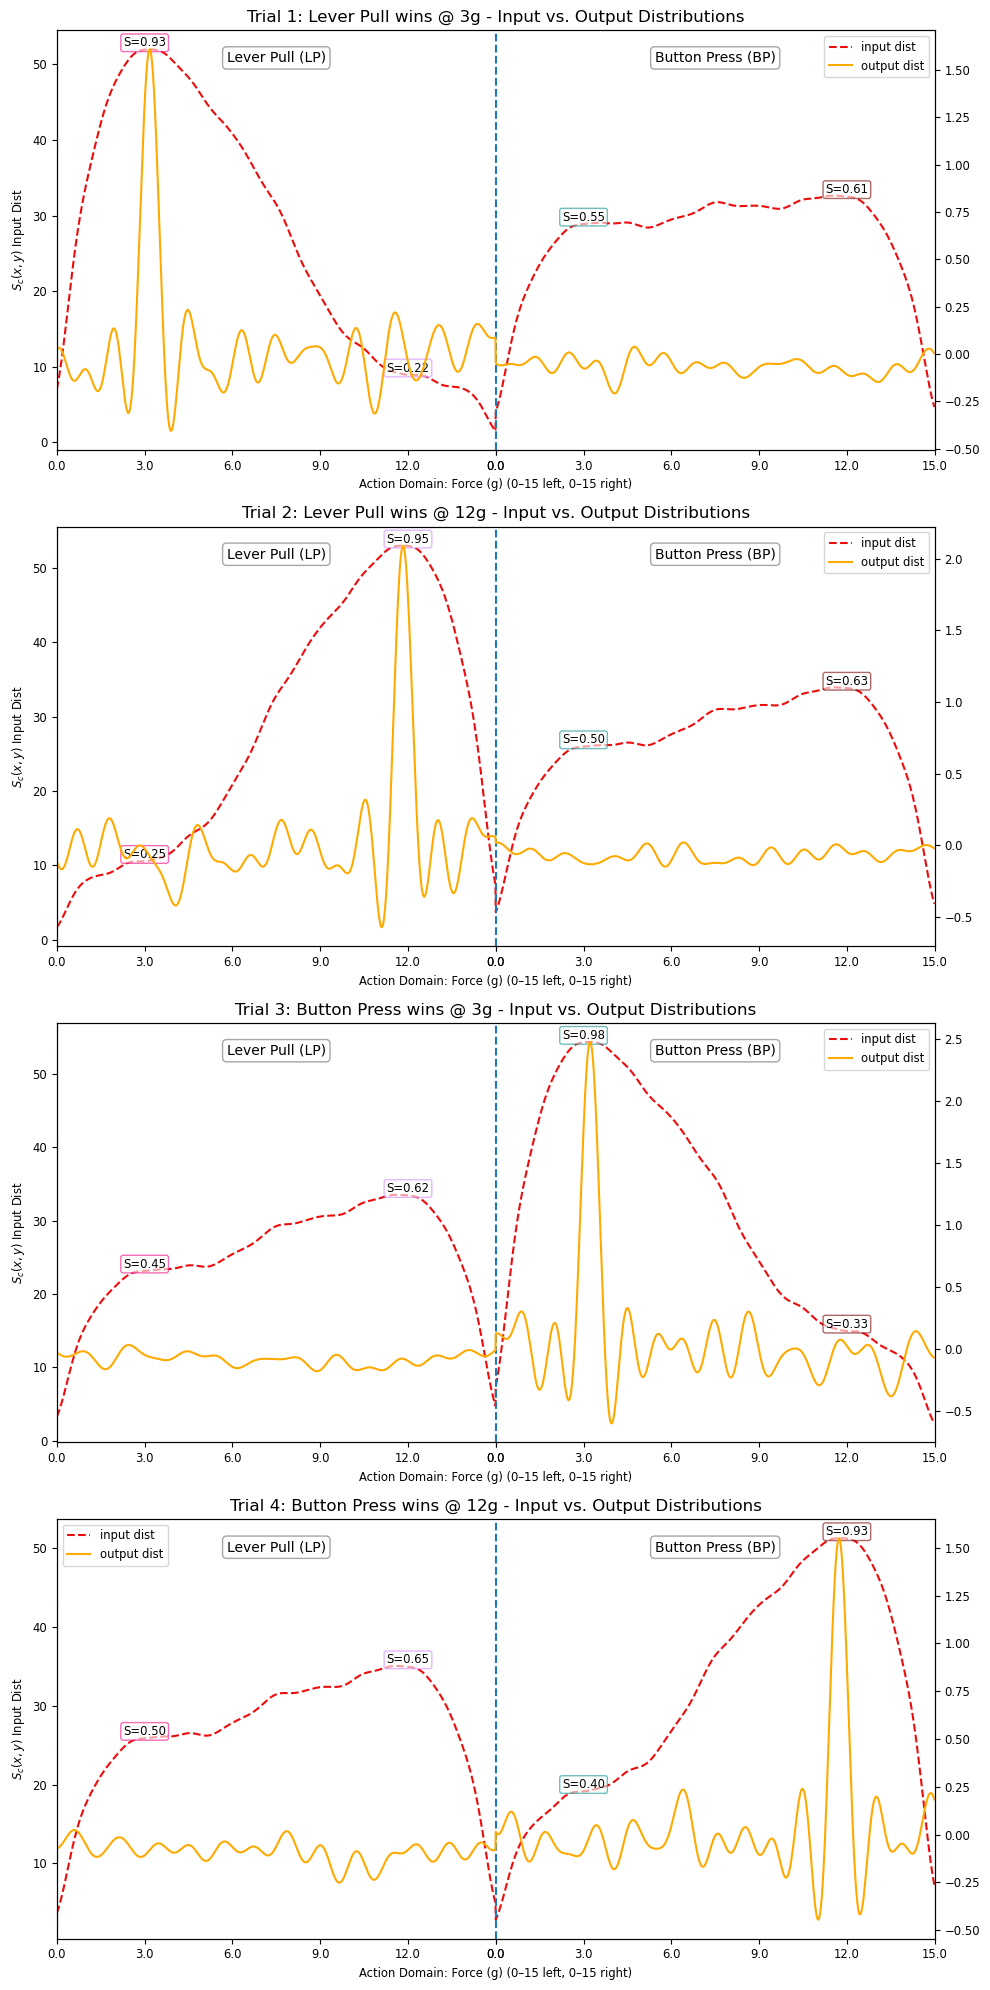

In [10]:
# trial_labels = ['L3 vs R12', 'L3 vs R12', 'L12 vs. R3', 'L12 vs. R3']
trial_labels = ['Lever Pull wins @ 3g', 'Lever Pull wins @ 12g', 'Button Press wins @ 3g', 'Button Press wins @ 12g']
data_trials = [run_trial1, run_trial2, run_trial3, run_trial4]
action_labels = ['Lever Pull (LP)', 'Button Press (BP)']
peak_labels = [300, 1200, 1800, 2700]
colors = ["#ef0a84", "#d289ff", "#0D9494", "#7a0303"]
salience_labels = [salience_t1, salience_t2, salience_t3, salience_t4]

# for each trial convert the bundle in and bundle out to distributions
# Trail 1 
bin_l3_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist1 = np.einsum('d,nd->n', run_trial1['bundle_ins'][1][-1], domain_phis_park)
bout_l3_dist1 = np.einsum('d,nd->n', run_trial1['bundle_out'][-1][0: 512], domain_phis_park)
bout_r12_dist1 = np.einsum('d,nd->n', run_trial1['bundle_out'][-1][512:], domain_phis_park)

# Trial 2
bin_l3_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][0][-1], domain_phis_park)
bin_r12_dist2 = np.einsum('d,nd->n', run_trial2['bundle_ins'][1][-1], domain_phis_park)
bout_l3_dist2 = np.einsum('d,nd->n', run_trial2['bundle_out'][-1][0: 512], domain_phis_park)
bout_r12_dist2 = np.einsum('d,nd->n', run_trial2['bundle_out'][-1][512:], domain_phis_park)

# Trial 3
bin_l12_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist3 = np.einsum('d,nd->n', run_trial3['bundle_ins'][1][-1], domain_phis_park)
bout_l12_dist3 = np.einsum('d,nd->n', run_trial3['bundle_out'][-1][0: 512], domain_phis_park)
bout_r3_dist3 = np.einsum('d,nd->n', run_trial3['bundle_out'][-1][512:], domain_phis_park)

# Trial 4
bin_l12_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][0][-1], domain_phis_park)
bin_r3_dist4 = np.einsum('d,nd->n', run_trial4['bundle_ins'][1][-1], domain_phis_park)
bout_l12_dist4 = np.einsum('d,nd->n', run_trial4['bundle_out'][-1][0: 512], domain_phis_park)
bout_r3_dist4 = np.einsum('d,nd->n', run_trial4['bundle_out'][-1][512:], domain_phis_park)

bundle_in_park = [
    np.hstack([bin_l3_dist1, bin_r12_dist1]), # Trial 1
    np.hstack([bin_l3_dist2, bin_r12_dist2]), # Trial 2
    np.hstack([bin_l12_dist3, bin_r3_dist3]), # Trial 3
    np.hstack([bin_l12_dist4, bin_r3_dist4]), # Trial 4

]

bundle_out_park = [
    np.hstack([bout_l3_dist1, bout_r12_dist1]), # Trial 1
    np.hstack([bout_l3_dist2, bout_r12_dist2]), # Trial 2
    np.hstack([bout_l12_dist3, bout_r3_dist3]), # Trial 3
    np.hstack([bout_l12_dist4, bout_r3_dist4]), # Trial 4
]

# Plot 
fig, axes = plt.subplots(4, 1, figsize=(10, 20))
plt.subplots_adjust(hspace=0.8)

if n_actions_park == 1:
    axes = [axes]

N = domain_force_park.shape[0]
d = np.arange(0, 2 * N)

ticks = np.linspace(0, N, 6).astype(int)
labels = np.linspace(0, 15, 6).round(1)
ticks2 = ticks + N

for i, ax in enumerate(axes):
    # --- Input Distribution (Left Axis) ---
    ax.plot(d, bundle_in_park[i],
            ls='--', color="#ED0C0C", label="input dist")
    ax.set_xlabel("Action Domain: Force (g) (0–15 left, 0–15 right)", fontsize="small")
    ax.set_ylabel('$S_c(x,y)$ Input Dist', fontsize='small', rotation=90,
                  labelpad=10, va='center')
    ax.tick_params(axis='x', labelsize='small')
    ax.tick_params(axis='y', labelsize='small')
    ax.set_xlim(0, 2 * N)

    # --- Custom Ticks for 0–15 left and right ---
    all_ticks = np.concatenate([ticks, ticks2])
    all_labels = [f"{lab:.1f}" for lab in labels] + [f"{lab:.1f}" for lab in labels]
    ax.set_xticks(all_ticks)
    ax.set_xticklabels(all_labels)

    # --- Output Distribution (Right Axis) ---
    ax2 = ax.twinx()
    ax2.plot(d, bundle_out_park[i],
             ls='-', color="#ffaa00", label="output dist")
    ax2.tick_params(axis='y', labelsize='small')

    # --- Combined Legend ---
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc='best', fontsize='small')
    ax.set_title(f'Trial {i + 1}: {trial_labels[i]} - Input vs. Output Distributions')

    # --- Add Salience Labels Above Peaks ---
    for h, x_peak in enumerate(peak_labels):
        if x_peak < len(bundle_in_park[i]):   # guard against out-of-range
            y_peak = bundle_in_park[i][x_peak]
            ax.text(
                x_peak, y_peak + 0.05,   # just above the curve
                f"S={salience_labels[i][h]:.2f}",
                ha='center', va='bottom', fontsize='small',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[h], alpha=0.6)
            )

# --- Vertical Lines + Channel Labels ---
for i in range(4):
    for n in range(n_actions_park):
        xpos = n * N
        axes[i].axvline(xpos, linestyle='--')
        if n < n_actions_park - 1:
            next_xpos = (n + 1) * N
            x_text = (xpos + next_xpos) / 2
        else:
            x_text = xpos + N / 2
        y_text = axes[i].get_ylim()[1] * 0.95
        axes[i].text(
            x_text, y_text,
            f"{action_labels[n]}",
            ha='center', va='top',
            fontsize='medium',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7)
        )

plt.tight_layout()
# plt.savefig('./figures/park/bimodal/park_output.png')
plt.savefig('./figures/park/bimodal/paper_output.png')
plt.show()


